# Cài đặt các Thư viện sử dụng

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Cài đặt hiển thị dataFrame

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [16]:
data_df = pd.read_csv("data_train.csv", encoding = 'utf-8')
with open('vietnamese-stopwords.txt', 'r', encoding='utf-8') as file:
    stopWords = file.read().split('\n')

FileNotFoundError: [Errno 2] No such file or directory: 'data_train.csv'

# Khám phá dữ liệu

## Mẫu dữ liệu

In [5]:
data_df.sample(5)

title  \
1024  Tạo hành lang pháp lý đầy đủ cho sự phát triển nhanh, bền vững của ngành Dầu khí   
393                                  Nhánh cây rơi đè chết 2 người ở công viên Tao Đàn   
258                               Cảnh sát cưỡi ngựa xuyên vòng lửa ở trung tâm TP HCM   
244                                                  Bờ biển sạt lở đe dọa hơn 600 dân   
595          Hàng nghìn tỷ đồng và sổ đỏ, hơn 500 cây vàng bị kê biên vì án tham nhũng   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

## Xem thông tin

In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          1568 non-null   object
 1   text           1568 non-null   object
 2   author         1308 non-null   object
 3   source_domain  1568 non-null   object
 4   label          1568 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 61.4+ KB


## Xem mô tả

In [7]:
data_df.describe().round(1)

,label
count,1568.0
mean,0.2
std,0.4
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


## Xem số dòng và số cột của dữ liệu

In [8]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

1568
5


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [9]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

### Dữ liệu có bị thiếu không?

In [10]:
data_df['title'].isnull().sum()

0

In [11]:
data_df['text'].isnull().sum()

0

In [12]:
data_df['author'].isnull().sum()

260

In [13]:
data_df['source_domain'].isnull().sum()

0

In [14]:
data_df['label'].isnull().sum()

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [15]:
data_df.dtypes

title            object
text             object
author           object
source_domain    object
label             int64
dtype: object

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [16]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [17]:
open_object_dtype(data_df['title'])

{str}

In [18]:
open_object_dtype(data_df['text'])

{str}

In [19]:
open_object_dtype(data_df['author'])

{float, str}

In [20]:
open_object_dtype(data_df['source_domain'])

{str}

In [21]:
open_object_dtype(data_df['label'])

{int}

#### Kiểm tra phân bố các class có chênh lệch không?

label
0    82.206633
1    17.793367
Name: proportion, dtype: float64

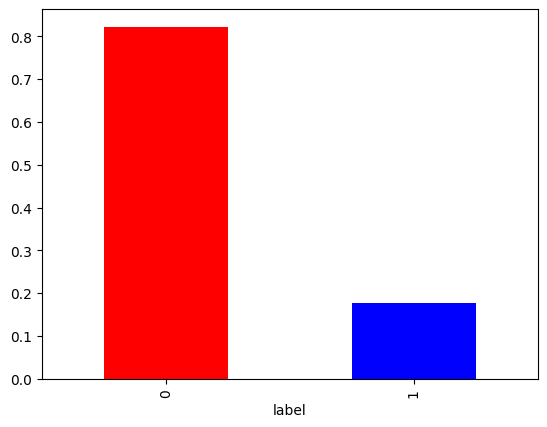

In [22]:
data_df.label.value_counts(normalize=True).plot(kind="bar", 
                                                color=["red", "blue"])
data_df['label'].value_counts(normalize=True) * 100

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [23]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

2871.7946428571427

##### Record dài nhất là bao nhiêu?

In [24]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

33691

##### Record ngắn nhất là bao nhiêu?

In [25]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

10

##### Tin tức được thu thập từ trang web nào nhiều nhất?

In [26]:
data_df['source_domain'].value_counts()

source_domain
vnexpress.net              660
dantri.com.vn              185
vietnamnet.vn              140
baomoi.com                 118
viettan.org                103
thanhnien.vn                86
tinvn.info                  68
thoibao.de                  47
nhandan.vn                  45
tuoitre.vn                  27
thethao.tuoitre.vn          10
thoibao.today                6
news.zing.vn                 6
tintucqpvn.net               5
www.webtretho.com            4
anninh247.xyz                4
phapluat.news                3
baophapluat.online           3
kinhdoanh.vnexpress.net      3
danviet.vn                   2
giadinhtiepthi.com           2
thegioitre.vn                2
www.ipick.vn                 2
doisong.vnexpress.net        2
giaitri.vnexpress.net        2
congtintuc24gio.com          2
2sao.vn                      1
vietgiaitri.com              1
trumpandq.blogspot.com       1
laodong.vn                   1
blogxcy.wordpress.com        1
tuvanannam.com           

### Tiền xử lí văn bản tiếng việt

#### Loại bỏ các đường link và các dấu câu, lowercase

In [1]:
def wordopt(text):
    text = text.lower()
    text = re.sub('https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('[^\w\s]', ' ', text) 
    text = re.sub('\n', ' ', text)
    return text


In [2]:
data_df["title"] = data_df["title"].apply(wordopt)
data_df["text"] = data_df["text"].apply(wordopt)
data_df["author"] = data_df["author"].apply(wordopt)
# data_df["source_domain"] = data_df["source_domain"].apply(wordopt)

NameError: name 'data_df' is not defined

In [29]:
data_df.head()

title  \
0            cấm biển  di dân khỏi vùng nguy hiểm từ quảng ninh đến nghệ an   
1                        tàu cao tốc đi phú quốc  côn đảo  lý sơn dừng chạy   
2           đêm nay siêu bão yagi vào vịnh bắc bộ  gây mưa lớn và giông lốc   
3  đề xuất người nổi tiếng chỉ được quảng cáo sản phẩm đã trực tiếp sử dụng   
4                                        di dời hơn 13 000 hộ dân trước bão   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

#### Tokenizer

In [30]:
def tokenize(sentence):
    return word_tokenize(sentence, format = 'word')

### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector, sử dụng CountVectorizer của sklearn
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

In [31]:
vectorizer = CountVectorizer(
    stop_words = stopWords,
    tokenizer = tokenize
)

Chia tập dữ liệu thành 2 tập

- Tập train: 75%
- Tập test: 25%


In [32]:
data_df["combined"] = data_df["title"] + " _ " + data_df["text"] + " _ " + data_df["author"] + " _ " + data_df["source_domain"]
X = data_df["combined"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)
Xv_train = vectorizer.fit_transform(X_train)
Xv_test = vectorizer.transform(X_test)

In [33]:
joblib.dump(vectorizer, 'vectorizer.joblib')

['vectorizer.joblib']

### Decision Tree

In [34]:
DT = DecisionTreeClassifier()
DT.fit(Xv_train,y_train)

DecisionTreeClassifier()

In [35]:
pred_dt = DT.predict(Xv_test)
print(DT.score(Xv_test, y_test))
#save model Decision Tree
joblib.dump(DT, 'DT_model.joblib')

0.9668367346938775


['DT_model.joblib']

### Naive Bayes

In [36]:
NB = MultinomialNB()
NB.fit(Xv_train,y_train)

MultinomialNB()

In [37]:
pred_nb = DT.predict(Xv_test)
print(NB.score(Xv_test, y_test))
#save model Naive Bayes
joblib.dump(NB, 'NB_model.joblib')

0.951530612244898


['NB_model.joblib']

### Đánh giá mô hình

- Mô hình với Decesion Tree  có độ chính xác cao khoảng 95%
- Mô hình với Naive Bayes có độ chính xác cao khoảng 95%